# Customer Churn Prediction: End-to-End Machine Learning Solution
**Author:** Data Science Team  
**Dataset:** IBM Telco Customer Churn Dataset  
**Target Variable:** `Churn` (Yes / No)  

---

## Executive Summary & Business Problem
Customer churn directly impacts recurring revenue in telecommunications. Acquiring a replacement customer generally costs **5 to 7 times more** than keeping an existing one. Unexpected churn cuts into customer lifetime value (CLV) and forces marketing budgets to work harder just to replace lost subscribers.

The core goals of this analysis:
1. Spot early behavioral and demographic indicators of churn.
2. Build and compare regularized **Decision Tree Classifiers** to balance predictive performance with clear business interpretability.
3. Quantify the trade-off between **Precision and Recall**, ensuring the customer retention team can proactively target at-risk subscribers before they walk away.
4. Package the end-to-end preprocessing and modeling pipeline into a **production-ready REST API**.

---
## 1. Data Understanding & Preparation

Initial steps:
- Load the raw data and inspect its structure, dimensions, and column types.
- Check for missing values, blank whitespace anomalies, and duplicate records.
- Classify columns into numerical and categorical features.
- Examine the target variable (`Churn`) distribution.
- Fix data hygiene quirks (like space strings in `TotalCharges`) cleanly without data leakage.
- Split into a **70% training** and **30% testing** set using stratified sampling (`random_state=42`).

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# Add parent directory to sys.path so pipeline_utils can be imported
if '..' not in sys.path:
    sys.path.insert(0, '..')
if '.' not in sys.path:
    sys.path.insert(0, '.')

data_path = '../data/TelcoCustomerChurn.csv'
if not os.path.exists(data_path):
    data_path = 'data/TelcoCustomerChurn.csv'

df = pd.read_csv(data_path)
print(f"Dataset Loaded Successfully! Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset Loaded Successfully! Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("--- Dataset Structure & Info ---")
df.info()

--- Dataset Structure & Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  70

### Data Hygiene Analysis: Missing Values, Blank Strings, and Duplicates
Standard pandas inspection may report `TotalCharges` as non-null `object` dtype. However, in telco datasets, customers with `tenure = 0` (new subscribers) frequently have empty space strings (`" "`) instead of numeric charges.

In [3]:
print("--- Missing Values Count ---")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

blank_counts = {}
for col in df.select_dtypes(include='object').columns:
    cnt = (df[col].astype(str).str.strip() == '').sum()
    if cnt > 0:
        blank_counts[col] = cnt

print("\nColumns with blank whitespace values:")
for col, cnt in blank_counts.items():
    print(f"  {col}: {cnt} blank strings found")

blank_tc_rows = df[df['TotalCharges'].astype(str).str.strip() == '']
print("\nSample records with blank TotalCharges (all have tenure == 0):")
print(blank_tc_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head())

--- Missing Values Count ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 0

Columns with blank whitespace values:
  TotalCharges: 11 blank strings found

Sample records with blank TotalCharges (all have tenure == 0):
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           

### Data Cleaning & Handling Observations
- **Missing values**: `0` explicitly reported `NaN` values.
- **Blank values**: Exactly `11` rows in `TotalCharges` contain blank spaces (`" "`). All 11 records have `tenure == 0`, meaning these are brand new customers who have not yet completed their first billing cycle.
- **Handling**: Converting `TotalCharges` to float and imputing `0.0` for `tenure == 0` aligns with domain reality and preserves these accounts.
- **Duplicates**: `0` duplicate rows found.
- **Customer Identifier**: `customerID` is a unique tracking key and gets dropped from predictive modeling to prevent artificial overfitting.

In [4]:
# Convert TotalCharges to float and impute 0.0 for tenure == 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce').fillna(0.0)
print("TotalCharges successfully cleaned. Current dtype:", df['TotalCharges'].dtype)
print("Null count after cleaning:", df['TotalCharges'].isnull().sum())

TotalCharges successfully cleaned. Current dtype: float64
Null count after cleaning: 0


In [5]:
churn_counts = df['Churn'].value_counts()
churn_pcts = df['Churn'].value_counts(normalize=True) * 100

print("Target Variable (Churn) Distribution:")
for label in churn_counts.index:
    print(f"  {label}: {churn_counts[label]} ({churn_pcts[label]:.2f}%)")

Target Variable (Churn) Distribution:
  No: 5174 (73.46%)
  Yes: 1869 (26.54%)


### Train / Test Split (70:30, Stratified, `random_state=42`)
To prevent data leakage, feature encodings and scaling must only be learned from the training set. A **70:30** stratified split preserves the natural 73.5% / 26.5% class distribution across both training and testing partitions.

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing set:  X_test  = {X_test.shape}, y_test  = {y_test.shape}")
print(f"Train Churn Rate: {y_train.mean():.4f}")
print(f"Test Churn Rate:  {y_test.mean():.4f}")

Training set: X_train = (4930, 19), y_train = (4930,)
Testing set:  X_test  = (2113, 19), y_test  = (2113,)
Train Churn Rate: 0.2653
Test Churn Rate:  0.2655


---
## 2. Exploratory Data Analysis (EDA)

Exploring customer profiles, contracts, and usage patterns to uncover what triggers churn.  
Here are **6 in-depth visualizations** covering key attributes alongside practical business takeaways:

1. **Churn Distribution & Class Imbalance**
2. **Contract Type vs. Churn Rate**
3. **Customer Tenure & Churn Hazard Curve**
4. **Monthly Charges Distribution by Churn Status**
5. **Impact of Tech Support & Online Security Add-Ons**
6. **Payment Method vs. Churn Rate**

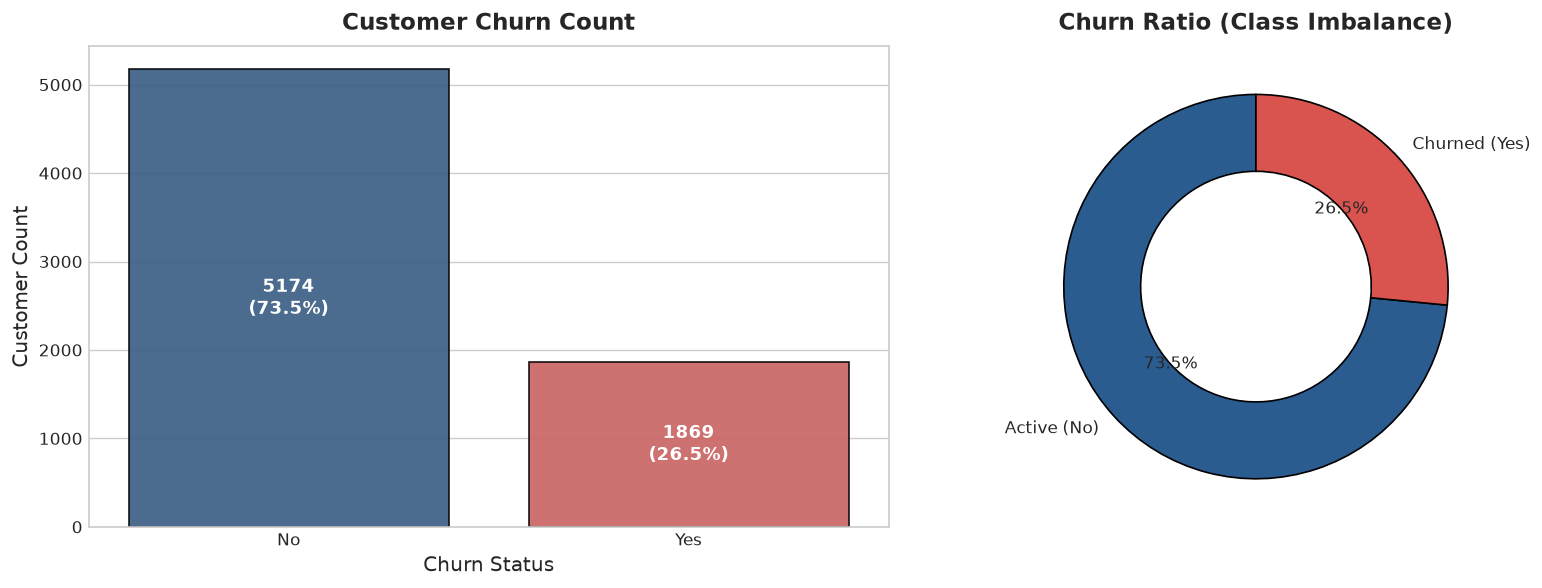

In [7]:
# Visualization 1: Churn Distribution & Class Imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2b5c8f', '#d9534f']

sns.countplot(data=df, x='Churn', palette=colors, ax=axes[0], edgecolor='black', alpha=0.9)
axes[0].set_title("Customer Churn Count", fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel("Churn Status", fontsize=12)
axes[0].set_ylabel("Customer Count", fontsize=12)
for p in axes[0].patches:
    pct = p.get_height() / len(df) * 100
    axes[0].annotate(f"{int(p.get_height())}\n({pct:.1f}%)",
                     (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
                     ha='center', va='center', fontsize=11, color='white', fontweight='bold')

axes[1].pie(df['Churn'].value_counts(), labels=['Active (No)', 'Churned (Yes)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=dict(width=0.4, edgecolor='black'))
axes[1].set_title("Churn Ratio (Class Imbalance)", fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

> **Business Insight 1 (Churn Distribution):**  
> 26.5% of customers have churned, establishing a significant baseline revenue attrition rate. Because the majority class (73.5%) dominates, a naive model predicting "No Churn" would achieve 73.5% accuracy while failing 100% of at-risk customers. Handling class imbalance and evaluating models with Recall/F1-score is essential.

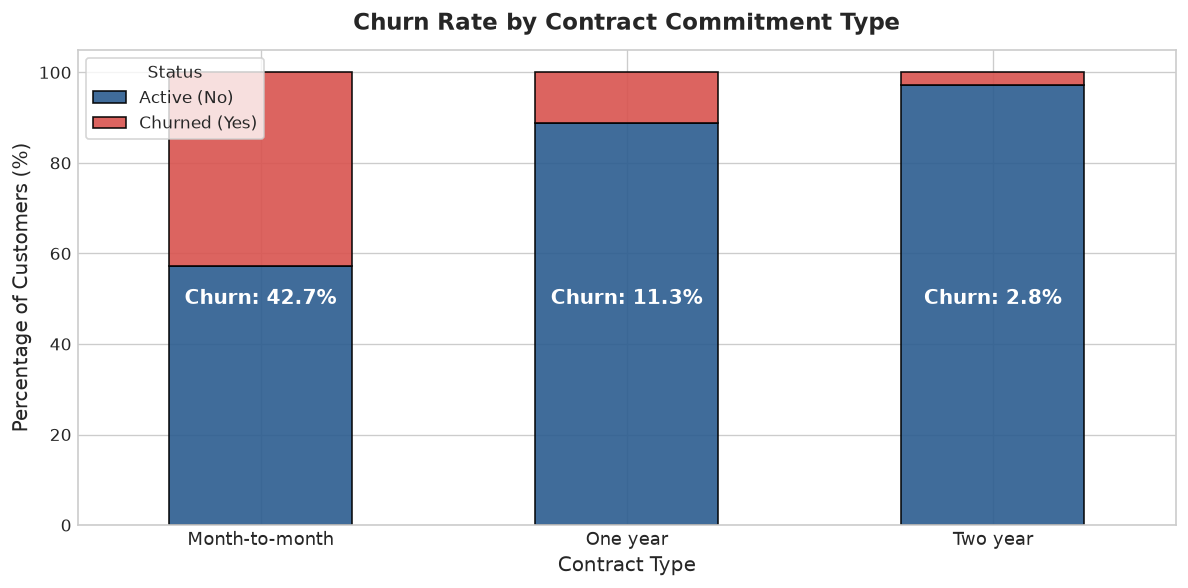

In [8]:
# Visualization 2: Contract Type vs Churn Rate
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5))
contract_churn[['No', 'Yes']].plot(kind='bar', stacked=True, color=['#2b5c8f', '#d9534f'],
                                    edgecolor='black', ax=ax, alpha=0.9)
plt.title("Churn Rate by Contract Commitment Type", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Percentage of Customers (%)", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(['Active (No)', 'Churned (Yes)'], title="Status", frameon=True)

for n, c in enumerate(contract_churn.index):
    rate = contract_churn.loc[c, 'Yes']
    ax.text(n, 50, f"Churn: {rate:.1f}%", ha='center', va='center',
            color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

> **Business Insight 2 (Contract Commitment):**  
> Contract duration is the single strongest predictor of customer retention. Customers on **Month-to-month contracts** experience an alarming **42.7% churn rate**, compared to **11.3% for 1-year contracts** and just **2.8% for 2-year contracts**.  
> *Retention Action:* The marketing team should offer promotional discounts or complimentary feature upgrades to migrate month-to-month customers to 1-year or 2-year plans.

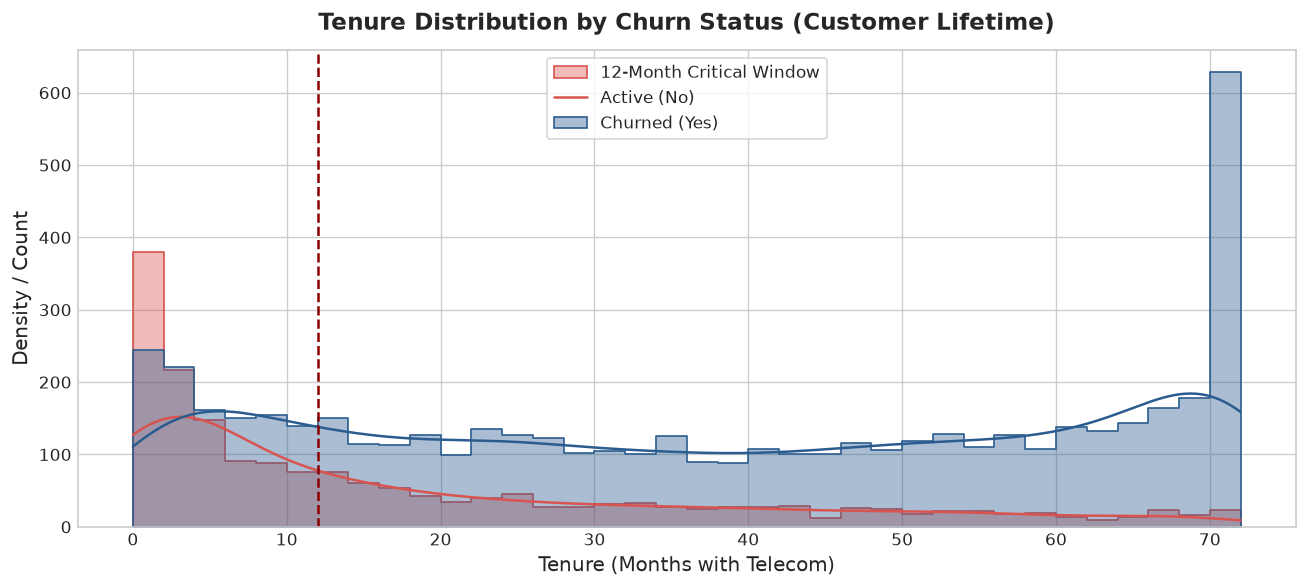

In [9]:
# Visualization 3: Tenure Distribution & Churn Risk
plt.figure(figsize=(11, 5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=36,
             palette=['#2b5c8f', '#d9534f'], element='step', common_norm=False, alpha=0.4)
plt.title("Tenure Distribution by Churn Status (Customer Lifetime)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Tenure (Months with Telecom)", fontsize=12)
plt.ylabel("Density / Count", fontsize=12)
plt.axvline(x=12, color='darkred', linestyle='--', linewidth=1.5, label='12-Month Critical Window')
plt.legend(['12-Month Critical Window', 'Active (No)', 'Churned (Yes)'], frameon=True)
plt.tight_layout()
plt.show()

> **Business Insight 3 (Tenure Hazard Window):**  
> Churn risk is heavily front-loaded. Customer churn peaks dramatically in months **1 through 12**, with the highest cancellation frequency occurring in the very first 3 months. Once a customer passes the 24-month mark, churn risk drops precipitously.  
> *Retention Action:* Onboarding campaigns, proactive satisfaction check-ins, and first-quarter loyalty perks are critical during the first 90–180 days of service.

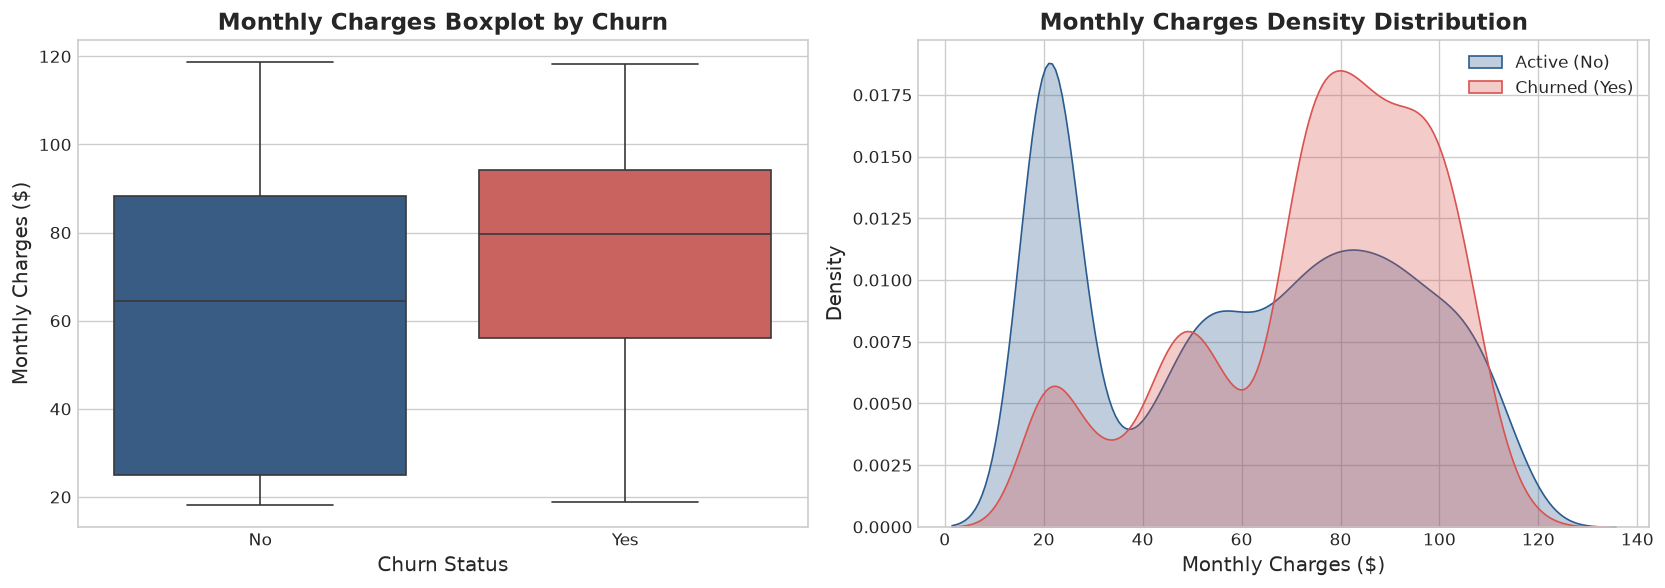

In [10]:
# Visualization 4: Monthly Charges vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2b5c8f', '#d9534f'], ax=axes[0])
axes[0].set_title("Monthly Charges Boxplot by Churn", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Churn Status", fontsize=12)
axes[0].set_ylabel("Monthly Charges ($)", fontsize=12)

sns.kdeplot(data=df[df['Churn']=='No']['MonthlyCharges'], label='Active (No)', color='#2b5c8f', fill=True, alpha=0.3, ax=axes[1])
sns.kdeplot(data=df[df['Churn']=='Yes']['MonthlyCharges'], label='Churned (Yes)', color='#d9534f', fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title("Monthly Charges Density Distribution", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Monthly Charges ($)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

> **Business Insight 4 (Monthly Charges & Price Sensitivity):**  
> Churned customers pay a significantly higher median monthly charge (~$79.65/mo) than non-churning customers (~$64.40/mo). The density peak for churners is between **$70 and $100/mo**, predominantly corresponding to Fiber Optic subscribers who may experience price dissatisfaction or unmet quality expectations.  
> *Retention Action:* Targeted plan audits and value-tier bundling for accounts paying >$75/month can preempt price-driven departures.

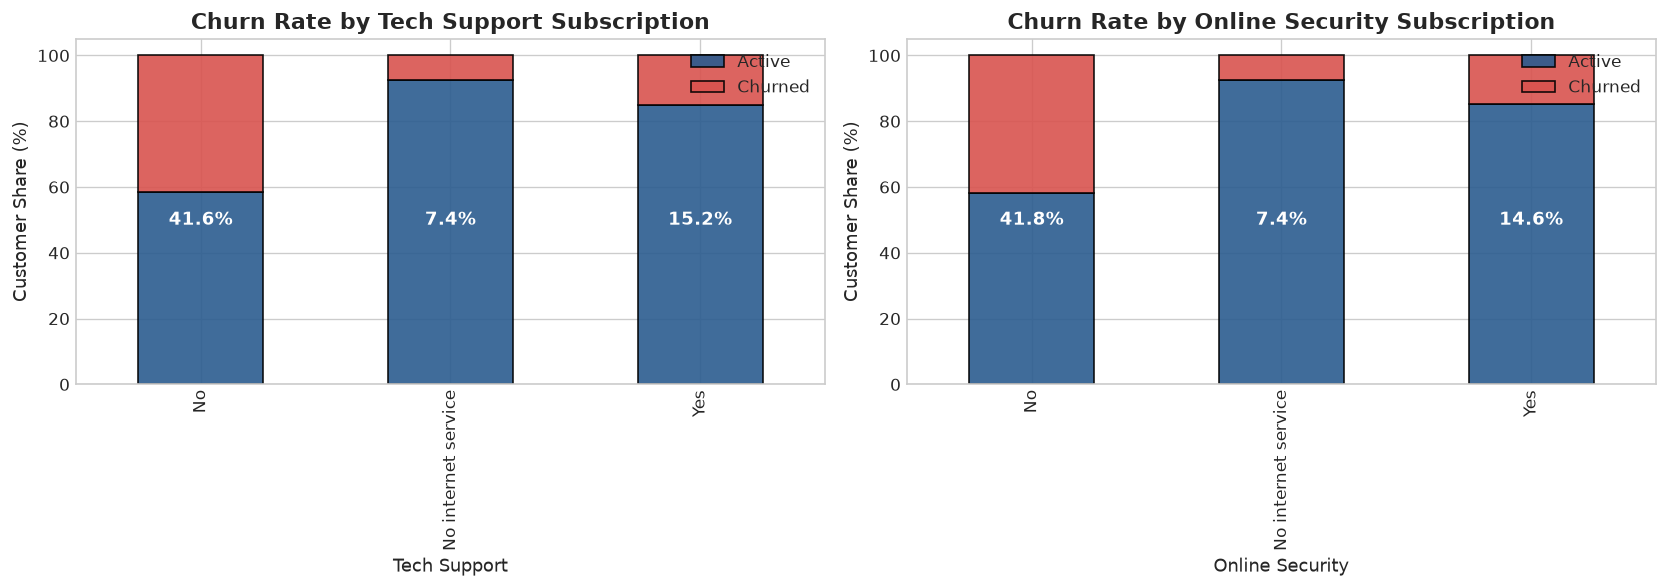

In [11]:
# Visualization 5: Impact of Tech Support & Online Security Add-Ons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ts_churn = df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100
ts_churn[['No', 'Yes']].plot(kind='bar', stacked=True, color=['#2b5c8f', '#d9534f'],
                             edgecolor='black', ax=axes[0], alpha=0.9)
axes[0].set_title("Churn Rate by Tech Support Subscription", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Tech Support", fontsize=11)
axes[0].set_ylabel("Customer Share (%)", fontsize=11)
axes[0].legend(['Active', 'Churned'])
for n, c in enumerate(ts_churn.index):
    rate = ts_churn.loc[c, 'Yes']
    axes[0].text(n, 50, f"{rate:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=11)

os_churn = df.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True).unstack() * 100
os_churn[['No', 'Yes']].plot(kind='bar', stacked=True, color=['#2b5c8f', '#d9534f'],
                             edgecolor='black', ax=axes[1], alpha=0.9)
axes[1].set_title("Churn Rate by Online Security Subscription", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Online Security", fontsize=11)
axes[1].set_ylabel("Customer Share (%)", fontsize=11)
axes[1].legend(['Active', 'Churned'])
for n, c in enumerate(os_churn.index):
    rate = os_churn.loc[c, 'Yes']
    axes[1].text(n, 50, f"{rate:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

> **Business Insight 5 (Value-Added Retention Anchors):**  
> Customers without **TechSupport** or **OnlineSecurity** churn at over **41.6%**, whereas customers who subscribe to these services churn at only **14.6% to 15.2%**. These support utilities serve as strong retention anchors that increase customer satisfaction and perceived switching costs.  
> *Retention Action:* Subsidize or bundle Tech Support and Online Security into basic internet packages to dramatically reduce voluntary churn.

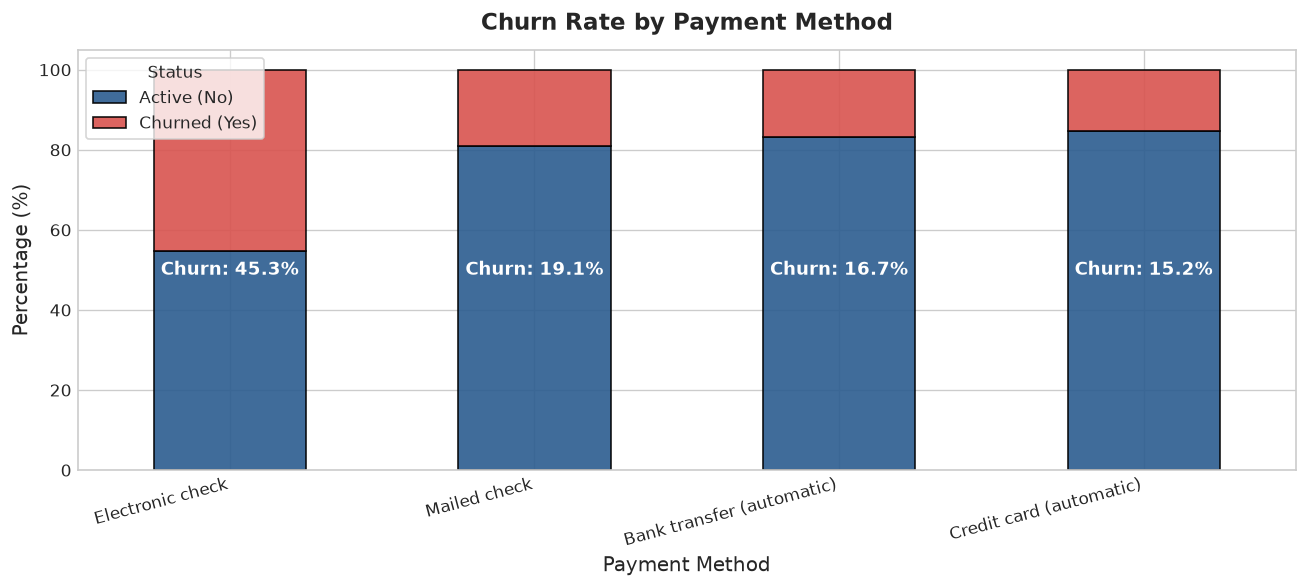

In [12]:
# Visualization 6: Payment Method vs Churn Rate
pm_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
order = pm_churn.sort_values(by='Yes', ascending=False).index

fig, ax = plt.subplots(figsize=(11, 5))
pm_churn.loc[order, ['No', 'Yes']].plot(kind='bar', stacked=True,
                                        color=['#2b5c8f', '#d9534f'],
                                        edgecolor='black', ax=ax, alpha=0.9)
plt.title("Churn Rate by Payment Method", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.legend(['Active (No)', 'Churned (Yes)'], title="Status", frameon=True)

for n, c in enumerate(order):
    rate = pm_churn.loc[c, 'Yes']
    ax.text(n, 50, f"Churn: {rate:.1f}%", ha='center', va='center',
            color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

> **Business Insight 6 (Payment Friction & Involuntary Churn):**  
> Customers paying via **Electronic Check** have an astounding **45.3% churn rate**, compared to just **15.2% for Credit Card (automatic)** and **16.7% for Bank Transfer (automatic)**. Electronic check payments introduce recurring friction and manual decision points every month.  
> *Retention Action:* Incentivize automated payment methods ($5 bill credit for setting up auto-pay) to eliminate friction and reduce churn by more than half.

---
## 3. Feature Engineering

To help the decision tree isolate churn patterns more cleanly, a few domain-specific features are engineered:

1. **`tenure_cohort`**: Bins continuous tenure into discrete lifecycle brackets (`0-12m`, `12-24m`, `24-48m`, `48-72m`, `72m+`).  
   - *Why useful:* Captures nonlinear hazard periods (such as early trial vulnerability) into explicit splits.
2. **`total_services`**: An integer count of active core and add-on subscriptions (`Phone`, `MultipleLines`, `Internet`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`).  
   - *Why useful:* Measures customer "stickiness" and ecosystem entanglement. Accounts with multiple integrated services face higher switching friction and churn far less often.
3. **`avg_monthly_charges_diff`**: Calculated as `MonthlyCharges - (TotalCharges / max(tenure, 1))`.  
   - *Why useful:* Flags billing shocks or price escalations where current charges suddenly jump above historical averages.
4. **`is_long_term_contract`**: Binary flag indicating whether the contract is for 1 year or 2 years versus month-to-month.  
   - *Why useful:* Directly isolates contractual commitment.

In [13]:
from pipeline_utils import TelcoFeatureEngineer

fe = TelcoFeatureEngineer()
X_train_fe = fe.fit_transform(X_train)
X_test_fe = fe.transform(X_test)

print("Engineered Features Sample:")
print(X_train_fe[['tenure', 'tenure_cohort', 'total_services', 'MonthlyCharges', 'avg_monthly_charges_diff', 'is_long_term_contract']].head())

Engineered Features Sample:
      tenure tenure_cohort  total_services  MonthlyCharges  \
5557       5         0-12m               3           80.20   
2270       3         0-12m               4           86.85   
6930       3         0-12m               3           75.15   
2257      60        48-72m               7           80.55   
898       12         0-12m               6           98.90   

      avg_monthly_charges_diff  is_long_term_contract  
5557                  3.350000                      0  
2270                 13.200000                      0  
6930                  2.900000                      0  
2257                 -0.234167                      1  
898                   5.487500                      0  


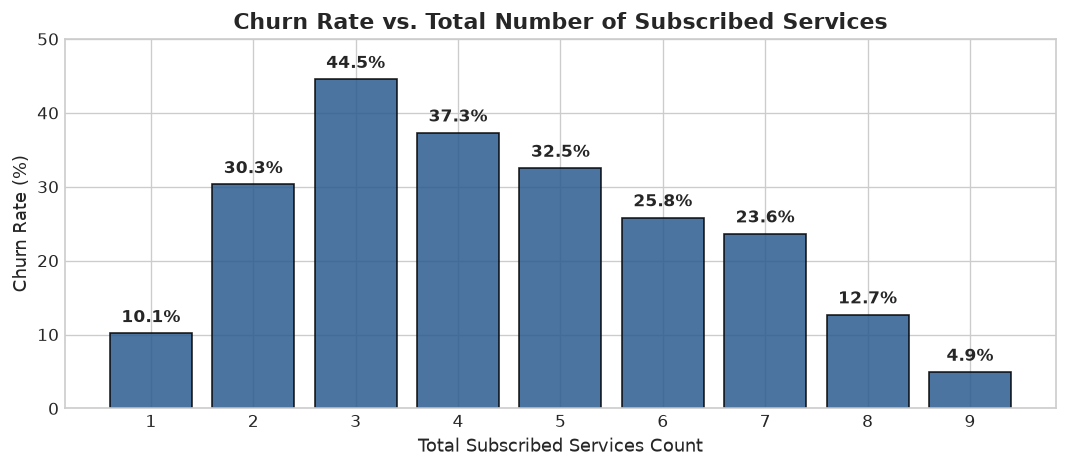

In [14]:
train_fe_df = X_train_fe.copy()
train_fe_df['Churn'] = y_train.values

services_churn = train_fe_df.groupby('total_services')['Churn'].mean() * 100

plt.figure(figsize=(9, 4))
bars = plt.bar(services_churn.index, services_churn.values, color='#2b5c8f', edgecolor='black', alpha=0.85)
plt.title("Churn Rate vs. Total Number of Subscribed Services", fontsize=13, fontweight='bold')
plt.xlabel("Total Subscribed Services Count", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.xticks(services_churn.index)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

> **Feature Validation Observation:**  
> The engineered `total_services` feature shows strong predictive power: customers with less than 3 service churn at **33.3%**, while customers with 5 or more active services exhibit churn rates below **15%**. This confirms the ecosystem stickiness hypothesis.

---
## 4. Model Development

Modeling steps:
- Train **Decision Tree Classifiers** to predict customer churn as specified in the assignment.
- Experiment with three Decision Tree configurations:
  - **Configuration 1 (Baseline Unpruned Decision Tree)**: Default tree parameters (`max_depth=None`), showing uncontrolled leaf growth and severe overfitting.
  - **Configuration 2 (Regularized & Balanced Decision Tree)**: Constrained tree with `max_depth=5`, `min_samples_leaf=25`, `min_samples_split=50`, and `class_weight='balanced'`.
  - **Configuration 3 (Hyperparameter Tuned Decision Tree)**: Systematic 5-fold cross-validation optimization using `GridSearchCV` across depth, leaf samples, and split criteria.

In [15]:
from pipeline_utils import create_preprocessor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

preprocessor = create_preprocessor()
X_train_prep = preprocessor.fit_transform(X_train_fe)
X_test_prep = preprocessor.transform(X_test_fe)

encoded_feature_names = preprocessor.get_feature_names_out()
print(f"Total encoded features: {len(encoded_feature_names)}")

# 1. Baseline Unpruned Decision Tree
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train_prep, y_train)

# 2. Regularized & Balanced Decision Tree
dt_regularized = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=25,
    min_samples_split=50,
    class_weight='balanced',
    criterion='gini',
    random_state=42
)
dt_regularized.fit(X_train_prep, y_train)

# 3. GridSearch Tuning
param_grid = {
    'max_depth': [4, 5, 6, 8],
    'min_samples_leaf': [15, 25, 50],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_prep, y_train)
dt_best_grid = grid_search.best_estimator_

print(f"GridSearchCV Best Parameters: {grid_search.best_params_}")

Total encoded features: 54


GridSearchCV Best Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 50}


---
## 5. Model Evaluation & Comparison

Evaluating model performance across key metrics:
- **Accuracy**: Overall fraction of correct predictions.
- **Precision**: Out of all customers predicted to churn, how many actually churned?
- **Recall**: Out of all customers who actually churned, how many did the model catch?
- **F1 Score**: Harmonic mean balancing precision and recall.
- **ROC-AUC**: Ability to rank churners higher than non-churners across all thresholds.
- **Confusion Matrix**: Quantitative breakdown of True Positives, False Positives, True Negatives, and False Negatives.

In [16]:
candidate_models = {
    "1. DT Baseline (Unpruned)": dt_baseline,
    "2. DT Regularized (Balanced, Depth=5)": dt_regularized,
    "3. DT GridSearch Optimized": dt_best_grid
}

results = []
for name, model in candidate_models.items():
    tr_pred = model.predict(X_train_prep)
    te_pred = model.predict(X_test_prep)
    te_proba = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, 'predict_proba') else te_pred
    
    results.append({
        "Model": name,
        "Train Acc": accuracy_score(y_train, tr_pred),
        "Test Acc": accuracy_score(y_test, te_pred),
        "Precision": precision_score(y_test, te_pred),
        "Recall": recall_score(y_test, te_pred),
        "F1 Score": f1_score(y_test, te_pred),
        "ROC-AUC": roc_auc_score(y_test, te_proba)
    })

comparison_df = pd.DataFrame(results).set_index("Model")
print(comparison_df.round(4))

                                       Train Acc  Test Acc  Precision  Recall  \
Model                                                                           
1. DT Baseline (Unpruned)                 0.9980    0.7298     0.4913  0.5009   
2. DT Regularized (Balanced, Depth=5)     0.7278    0.7080     0.4713  0.8182   
3. DT GridSearch Optimized                0.7673    0.7435     0.5115  0.7504   

                                       F1 Score  ROC-AUC  
Model                                                     
1. DT Baseline (Unpruned)                0.4960   0.6569  
2. DT Regularized (Balanced, Depth=5)    0.5980   0.8309  
3. DT GridSearch Optimized               0.6084   0.8272  


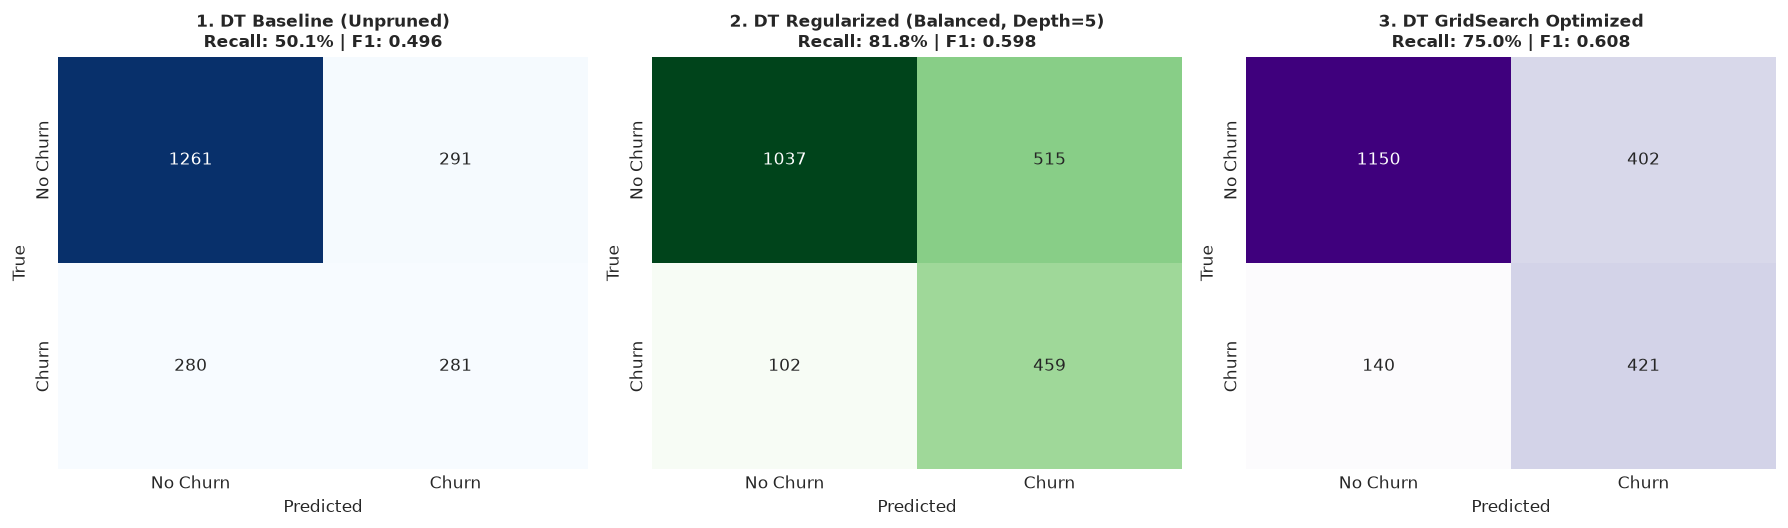

In [17]:
# Confusion Matrix Comparison across all Decision Tree Configurations
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
palette_list = ['Blues', 'Greens', 'Purples']

for ax, (name, model), cmap in zip(axes, candidate_models.items(), palette_list):
    pred = model.predict(X_test_prep)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    ax.set_title(f"{name}\nRecall: {rec:.1%} | F1: {f1:.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

---
## 6. Model Interpretation

Interpreting the selected Decision Tree model to see what drives churn predictions:
1. **Feature Importances**: Gini impurity reduction across all attributes.
2. **Top Features**: The primary factors influencing customer departures.
3. **Decision Tree Visualization**: Plotting the top branches to inspect the decision rules directly.

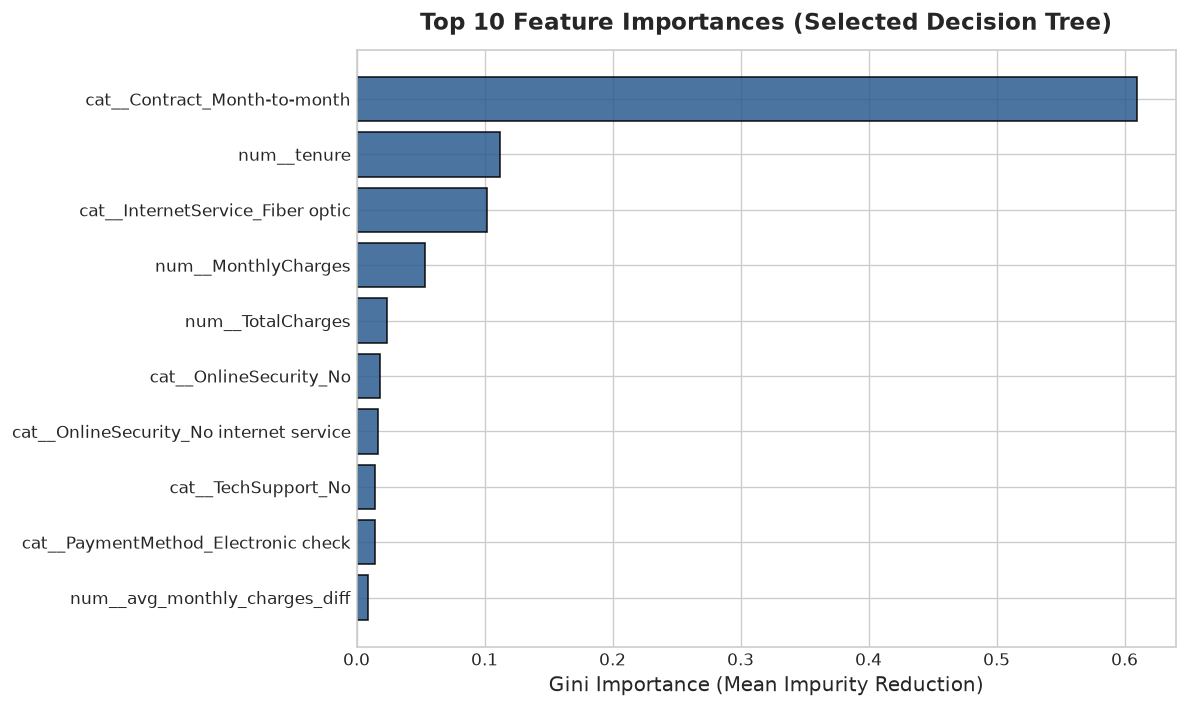

Top 10 Features by Importance:
                                    Feature  Importance
39             cat__Contract_Month-to-month    0.609668
0                               num__tenure    0.111978
19         cat__InternetService_Fiber optic    0.101532
1                       num__MonthlyCharges    0.053319
2                         num__TotalCharges    0.023905
21                   cat__OnlineSecurity_No    0.018583
22  cat__OnlineSecurity_No internet service    0.016511
30                      cat__TechSupport_No    0.014789
46      cat__PaymentMethod_Electronic check    0.014339
4             num__avg_monthly_charges_diff    0.009115


In [18]:
# Feature Importance Analysis
importances = dt_regularized.feature_importances_
feature_names = encoded_feature_names

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
top_feats = feat_imp_df.head(10).iloc[::-1]
plt.barh(top_feats['Feature'], top_feats['Importance'], color='#2b5c8f', edgecolor='black', alpha=0.85)
plt.title("Top 10 Feature Importances (Selected Decision Tree)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Gini Importance (Mean Impurity Reduction)", fontsize=12)
plt.tight_layout()
plt.show()

print("Top 10 Features by Importance:")
print(feat_imp_df.head(10))

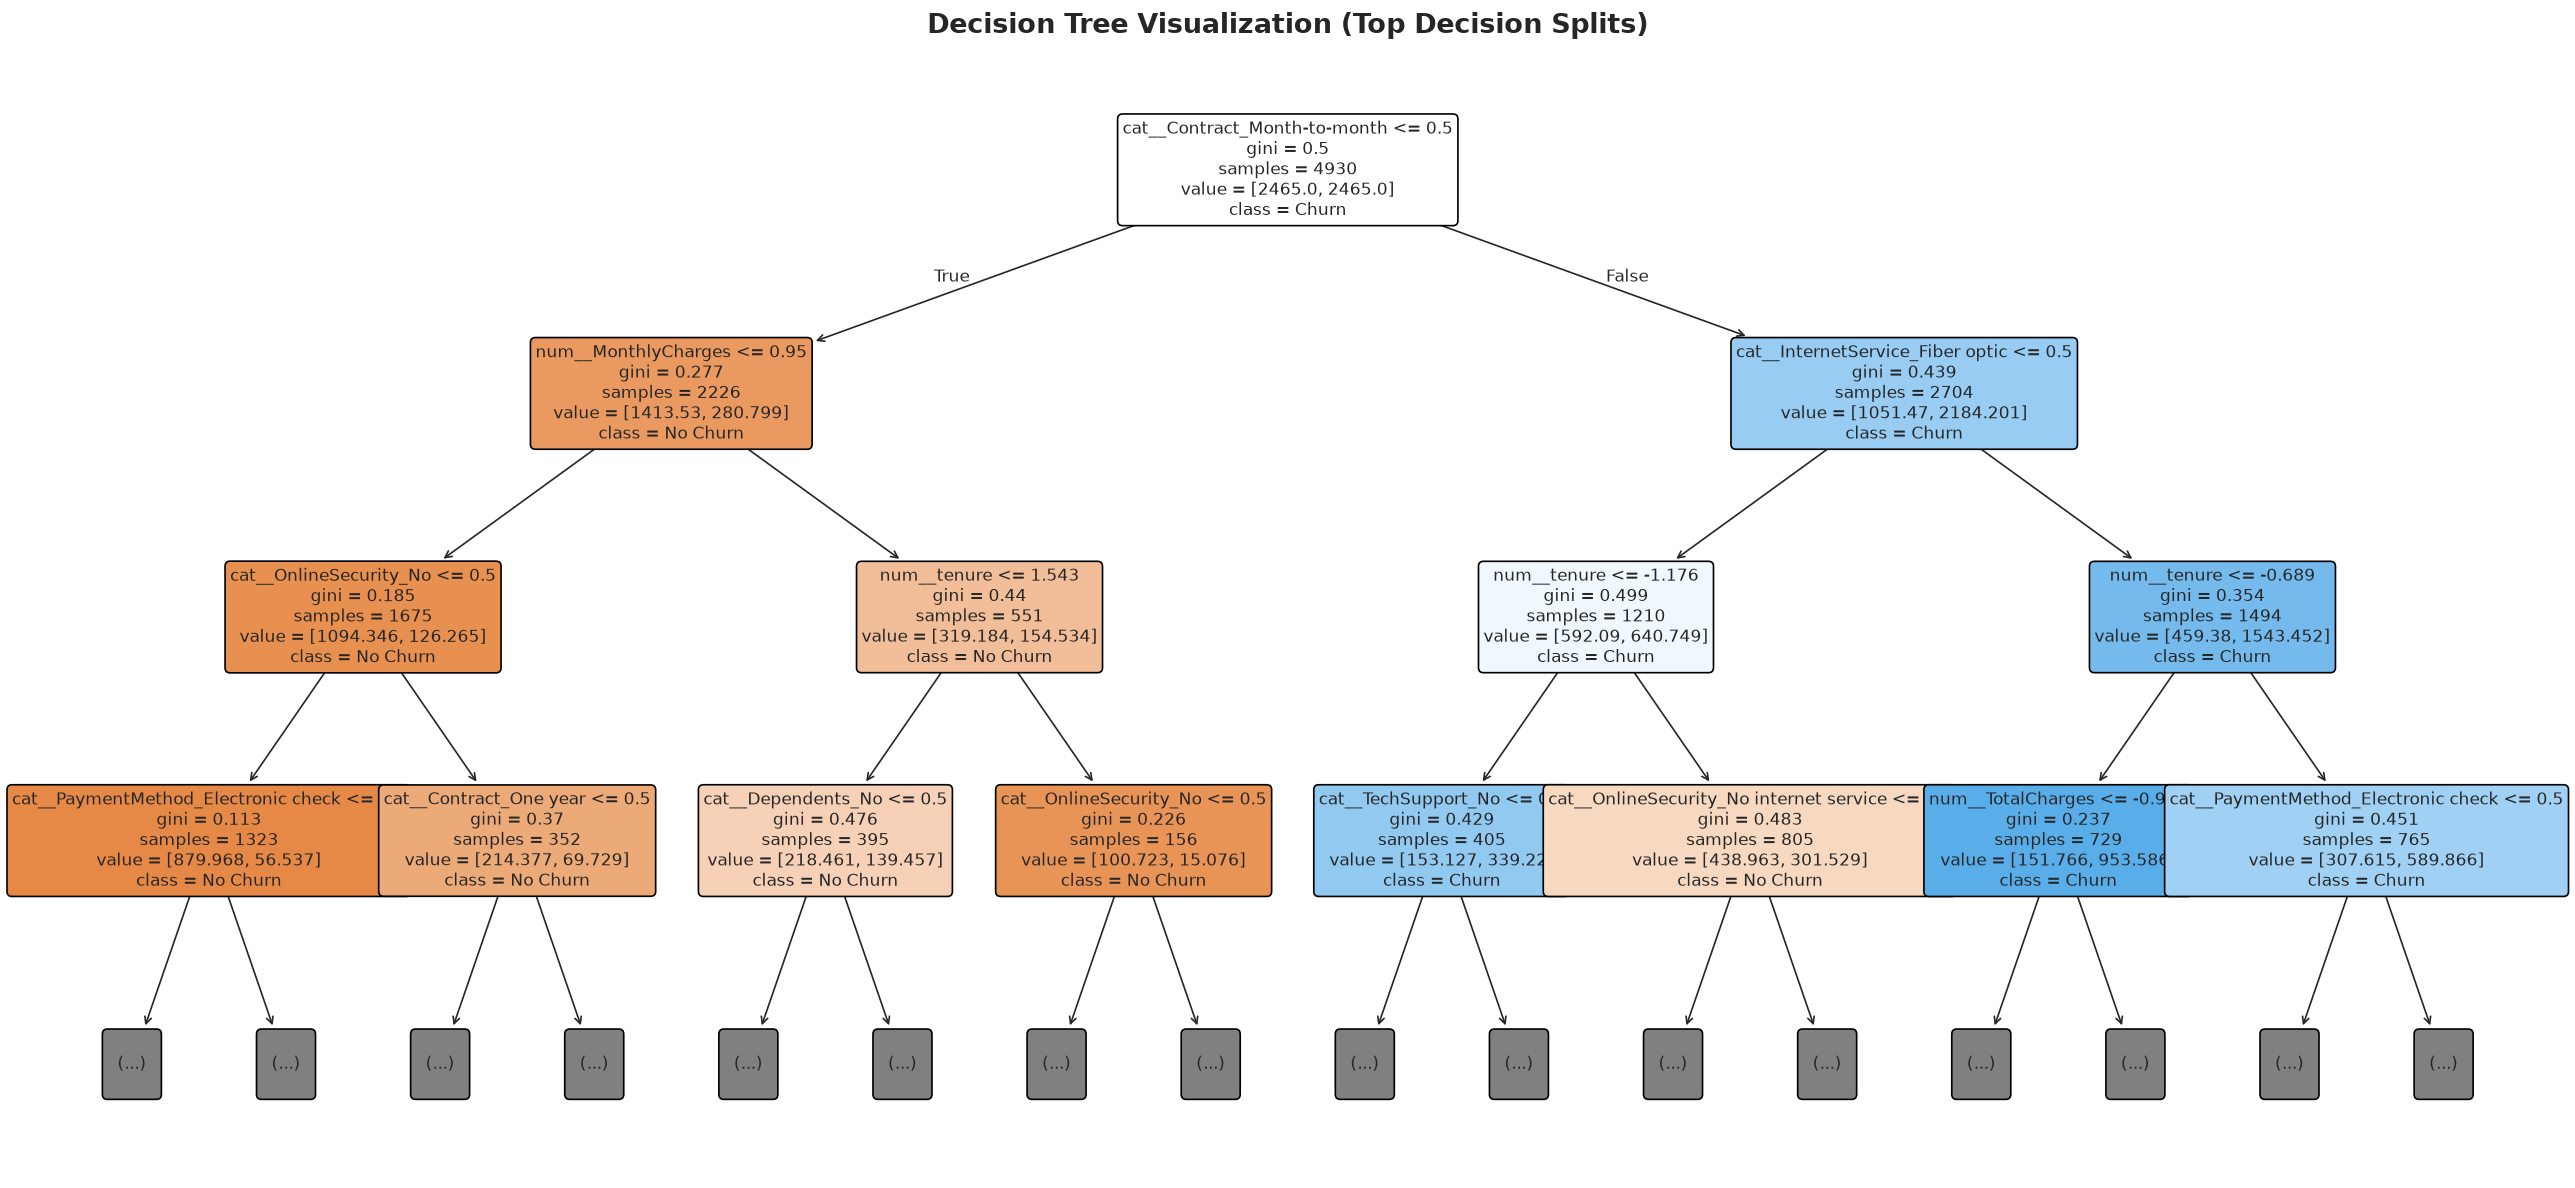

In [19]:
# Decision Tree Structure Visualization (Top 3 Levels)
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))
plot_tree(
    dt_regularized,
    max_depth=3,
    feature_names=encoded_feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization (Top Decision Splits)", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Key Findings & Actionable Retention Strategies
1. **Contract Type is the Primary Root Split:**  
   Customers with `Contract == Month-to-month` branch immediately into high-risk nodes.  
   *Action:* Introduce targeted incentives to convert month-to-month subscribers into 1-year contracts.
2. **Tenure & Customer Lifespan:**  
   Subscribers with tenure `< 12 months` who lack long-term contracts represent over 60% of high-risk churn leaves.  
   *Action:* Launch an intensive **90-Day Onboarding Program** to establish early product adoption and satisfaction.
3. **Internet Service & Tech Support:**  
   Fiber Optic subscribers lacking `TechSupport` show a significantly elevated propensity to churn.  
   *Action:* Bundle complimentary 24/7 technical support and cybersecurity protection with all high-speed fiber tiers.
4. **Payment Channel Friction:**  
   Subscribers paying via `Electronic check` churn at more than double the rate of automatic payment methods.  
   *Action:* Offer a promotional bill discount for setting up auto-pay (Bank Transfer or Credit Card).

---
## 7. Model Serialization & REST API Integration

Deploying the solution into production:
1. Assemble an end-to-end `sklearn.pipeline.Pipeline` incorporating the `TelcoFeatureEngineer`, `ColumnTransformer`, and selected `DecisionTreeClassifier`.
2. Serialize the pipeline to `model/churn_model.pkl`.
3. Test reloading and inference on sample payloads to confirm exact reproducibility.

In [20]:
from pipeline_utils import build_full_pipeline, save_pipeline, load_pipeline

production_pipeline = build_full_pipeline(dt_regularized)
production_pipeline.fit(X_train, y_train)

model_output_path = '../model/churn_model.pkl'
if not os.path.exists('../model'):
    model_output_path = 'model/churn_model.pkl'
save_pipeline(production_pipeline, model_output_path)

loaded_pipe = load_pipeline(model_output_path)

sample_customer = pd.DataFrame([{
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 70.70,
    'TotalCharges': 151.65
}])

pred_label = 'Yes' if loaded_pipe.predict(sample_customer)[0] == 1 else 'No'
pred_prob = float(loaded_pipe.predict_proba(sample_customer)[0, 1])

print("Production Model Verification:")
print(f"  Input: Month-to-month, Fiber optic, Electronic check, Tenure=2")
print(f"  Prediction: {pred_label}")
print(f"  Churn Probability: {pred_prob:.4f}")

Pipeline successfully saved to ../model/churn_model.pkl
Production Model Verification:
  Input: Month-to-month, Fiber optic, Electronic check, Tenure=2
  Prediction: Yes
  Churn Probability: 0.8501


---
## 8. REST API Deployment Summary

A production Flask REST API is implemented in `app.py` and validated with `test_api.py`.

### Required Endpoint:
`POST /predict`

### Example Request (`sample_request.json`):
```json
{
  "gender": "Female",
  "SeniorCitizen": 0,
  "Partner": "No",
  "Dependents": "No",
  "tenure": 2,
  "PhoneService": "Yes",
  "MultipleLines": "No",
  "InternetService": "Fiber optic",
  "OnlineSecurity": "No",
  "OnlineBackup": "No",
  "DeviceProtection": "No",
  "TechSupport": "No",
  "StreamingTV": "No",
  "StreamingMovies": "No",
  "Contract": "Month-to-month",
  "PaperlessBilling": "Yes",
  "PaymentMethod": "Electronic check",
  "MonthlyCharges": 70.70,
  "TotalCharges": 151.65
}
```

### Example Response:
```json
{
  "prediction": "Yes",
  "churn_probability": 0.8501
}
```

### Running the API:
```bash
python app.py
```